In [ ]:
# Predictive Analytics for GoodLife Fitness Attendance
# Problem 1: Predicting Number of People in the Gym
# Problem 2: Predicting Class Attendance

# -------------------------------
# 1. Data Import
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
# add comments


In [29]:

# Load datasets
gym_df = pd.read_csv('problem1.csv')  # For Problem 1
booking_df = pd.read_csv('problem2.csv')  # For Problem 2

# Preview data
display(gym_df.head())
display(booking_df.head())


,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


In [30]:
# -------------------------------
# 2. Data Cleaning
# -------------------------------
# Problem 1 Cleaning
gym_df['timestamp'] = pd.to_numeric(gym_df['timestamp'], errors='coerce')
gym_df['date'] = pd.to_datetime(gym_df['date'], errors='coerce')
gym_df['hour'] = pd.to_numeric(gym_df['hour'], errors='coerce')
gym_df = gym_df.dropna()

# Problem 2 Cleaning
booking_df['days_before'] = pd.to_numeric(booking_df['days_before'], errors='coerce')
booking_df['weight'] = pd.to_numeric(booking_df['weight'], errors='coerce')
booking_df['months_as_member'] = pd.to_numeric(booking_df['months_as_member'], errors='coerce')
booking_df = booking_df.dropna()
booking_df['day_of_week'] = booking_df['day_of_week'].astype('category')
booking_df['category'] = booking_df['category'].astype('category')
booking_df['time'] = booking_df['time'].astype('category')




In [31]:
# -------------------------------
# 3. Feature Engineering
# -------------------------------
# Problem 1 Features
gym_df['is_peak_hour'] = gym_df['hour'].between(17, 20).astype(int)
gym_df['day_of_week'] = gym_df['day_of_week'].astype('category')
gym_df['is_holiday'] = gym_df['is_holiday'].astype('category')

# One-hot encode gym_df
gym_df_encoded = pd.get_dummies(gym_df, columns=['day_of_week', 'is_holiday'])

# Problem 2 Features

booking_df['lead_time_bucket'] = pd.cut(booking_df['days_before'], 
                                         bins=[0, 1, 3, 7, 14, np.inf], 
                                         labels=['0-1', '2-3', '4-7', '8-14', '15+'], 
                                         right=False)
# 保留原始字段


booking_df = pd.get_dummies(booking_df, columns=['day_of_week', 'category', 'lead_time_bucket', 'time'])


In [32]:
# -------------------------------
# 4. Modeling
# -------------------------------
# Problem 1: Regression Model (Predicting number of people)

X1 = gym_df_encoded.drop(columns=['number_people', 'date'])
y1 = gym_df_encoded['number_people']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

reg_model = GradientBoostingRegressor()
reg_model.fit(X1_train, y1_train)
y1_pred = reg_model.predict(X1_test)

# Problem 2: Classification Model (Predicting class attendance)
X2 = booking_df.drop(columns=['booking_id', 'attended'])
y2 = booking_df['attended']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

clf_model = GradientBoostingClassifier()
clf_model.fit(X2_train, y2_train)
y2_pred = clf_model.predict(X2_test)
y2_proba = clf_model.predict_proba(X2_test)[:, 1]

In [33]:
# -------------------------------
# 5. Evaluation
# -------------------------------
# Problem 1: Regression Metrics
print("--- Problem 1: Gym Crowd Prediction ---")
print("RMSE:", mean_squared_error(y1_test, y1_pred, squared=False))
print("R^2 Score:", r2_score(y1_test, y1_pred))

# Problem 2: Classification Metrics
print("\n--- Problem 2: Class Attendance Prediction ---")
print(confusion_matrix(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))
print("AUC:", roc_auc_score(y2_test, y2_proba))


--- Problem 1: Gym Crowd Prediction ---
RMSE: 12.02649199543437
R^2 Score: 0.7201564215829168

--- Problem 2: Class Attendance Prediction ---
[[173  27]
 [ 55  36]]
              precision    recall  f1-score   support

           0       0.76      0.86      0.81       200
           1       0.57      0.40      0.47        91

    accuracy                           0.72       291
   macro avg       0.67      0.63      0.64       291
weighted avg       0.70      0.72      0.70       291

AUC: 0.797032967032967


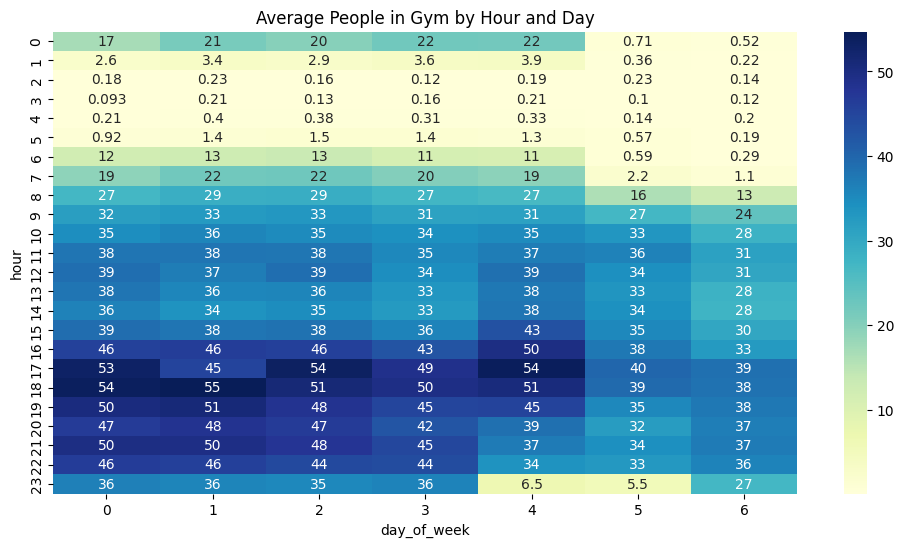

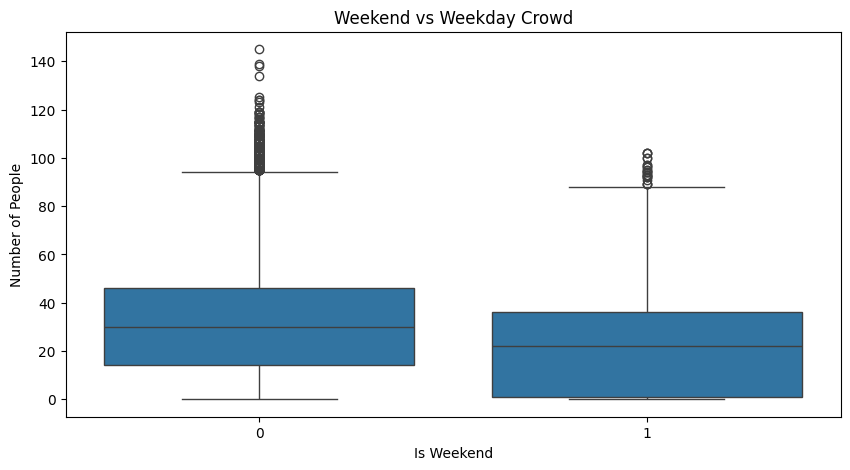

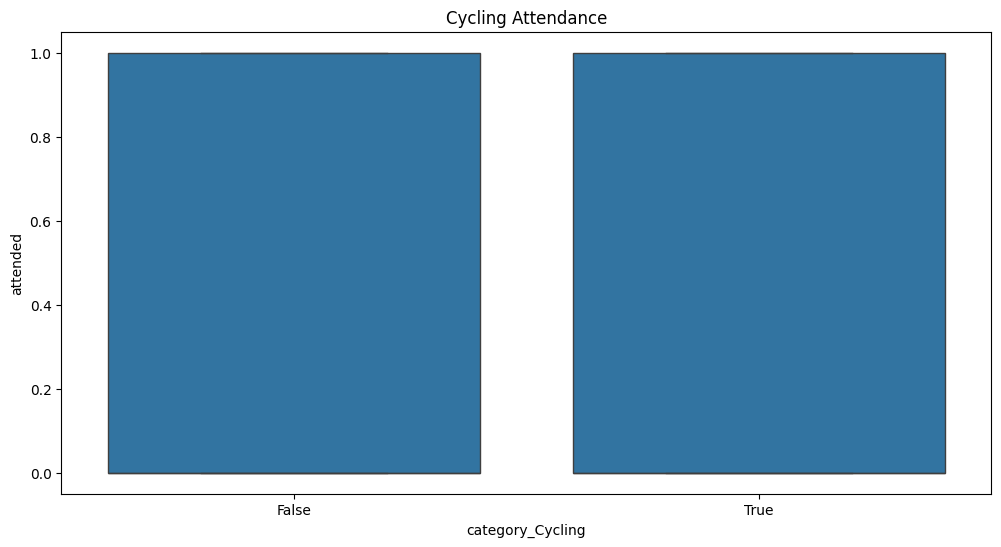

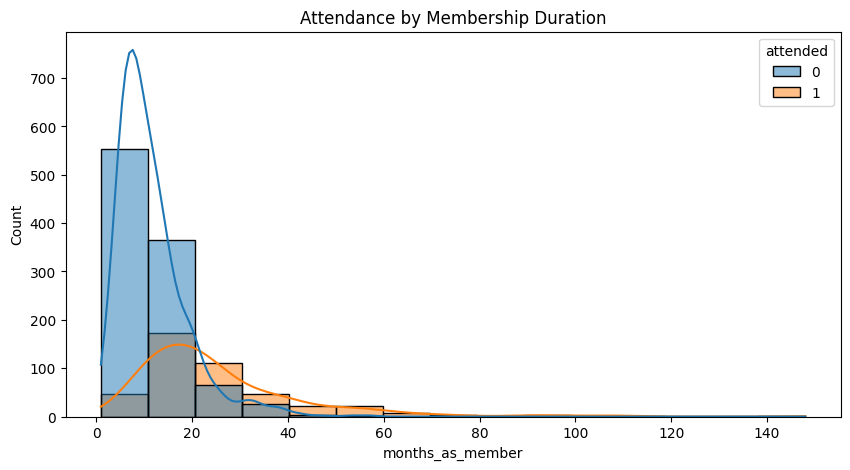

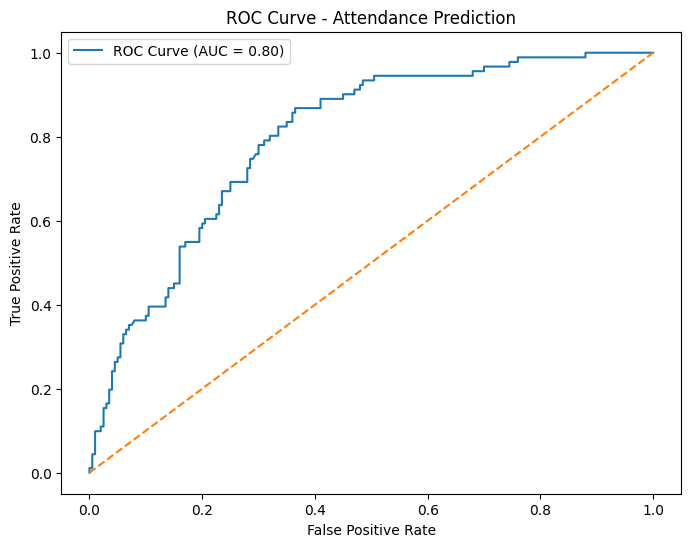

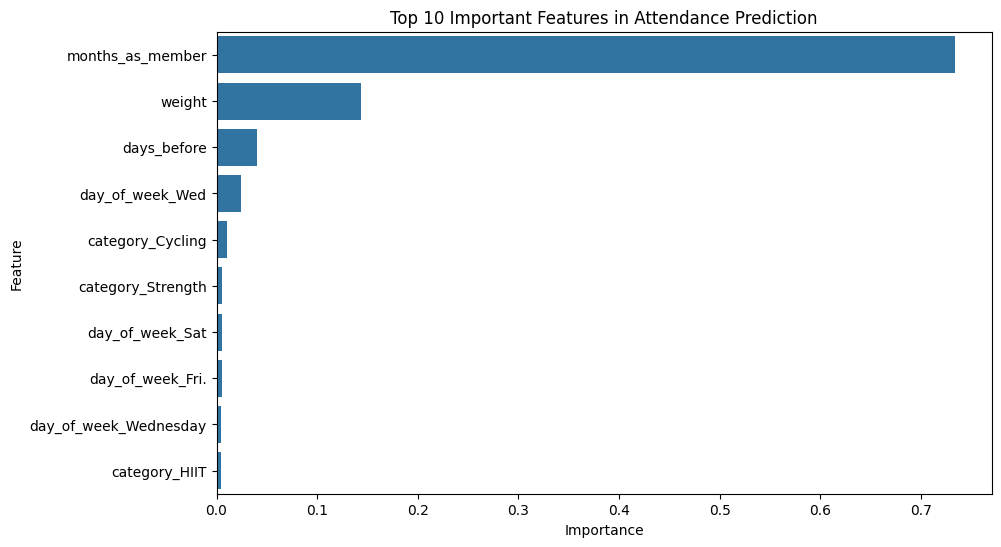

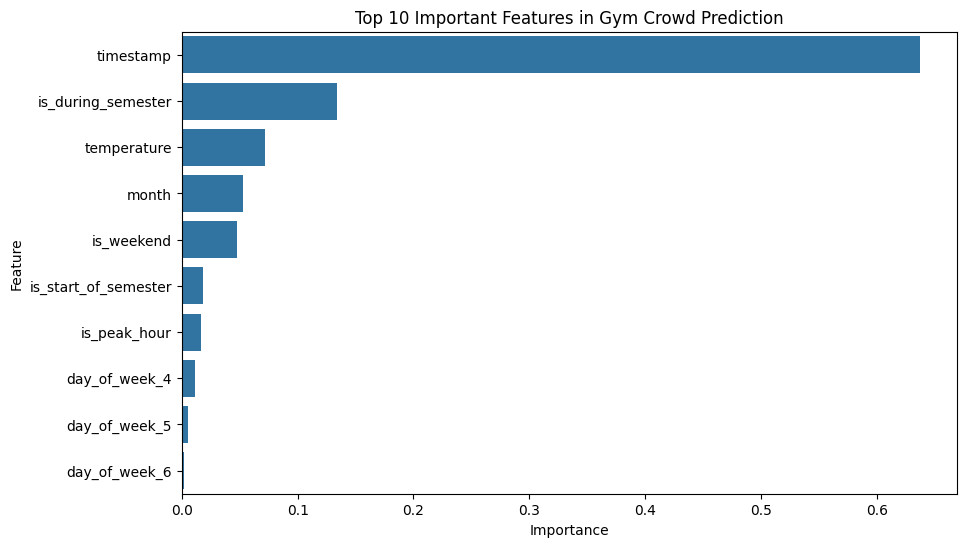

In [34]:
# -------------------------------
# 6. Visualizations
# -------------------------------
# Gym Crowd Heatmap
pivot = gym_df.pivot_table(index='hour', columns='day_of_week', values='number_people', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True)
plt.title('Average People in Gym by Hour and Day')
plt.show()

# Gym Crowd Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=gym_df, x='is_weekend', y='number_people')
plt.title('Weekend vs Weekday Crowd')
plt.xlabel('Is Weekend')
plt.ylabel('Number of People')
plt.show()

# Attendance Boxplot by Category
plt.figure(figsize=(12,6))
sns.boxplot(data=booking_df, x='category_Cycling', y='attended')
plt.title('Cycling Attendance')
plt.show()

# Attendance by Membership Length
plt.figure(figsize=(10,5))
sns.histplot(data=booking_df, x='months_as_member', hue='attended', bins=15, kde=True)
plt.title('Attendance by Membership Duration')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y2_test, y2_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc_score(y2_test, y2_proba))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Attendance Prediction')
plt.legend()
plt.show()

# Feature Importance - Attendance
importances = clf_model.feature_importances_
features = X2.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features in Attendance Prediction')
plt.show()

# Feature Importance - Gym Crowd
importances2 = reg_model.feature_importances_
features2 = X1.columns
feat_imp_df2 = pd.DataFrame({'Feature': features2, 'Importance': importances2})
feat_imp_df2 = feat_imp_df2.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df2.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features in Gym Crowd Prediction')
plt.show()


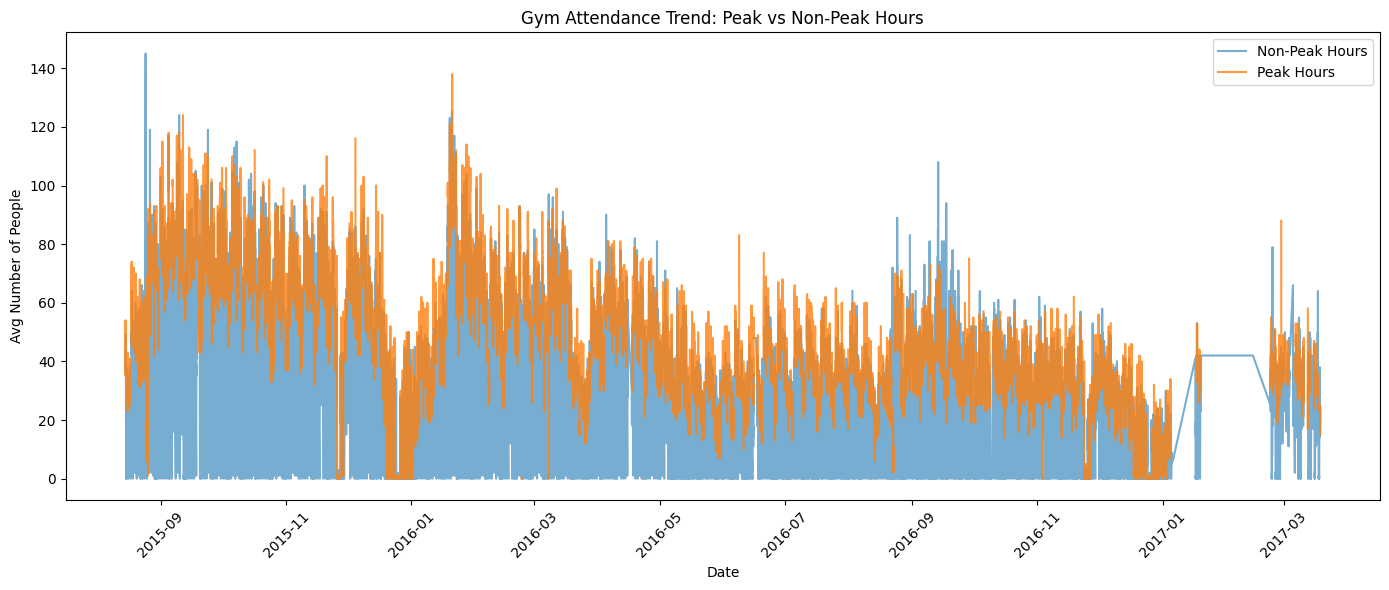

In [35]:
# -------------------------------
# Gym Attendance Over Time
# -------------------------------

# Time Series Line Chart for Daily Average Attendance
# Add peak hour flag again just in case
gym_df['is_peak_hour'] = gym_df['hour'].between(17, 20).astype(int)

# Daily trend split by peak hour
daily_peak_trend = gym_df.groupby(['date', 'is_peak_hour'])['number_people'].mean().reset_index()
pivot_peak = daily_peak_trend.pivot(index='date', columns='is_peak_hour', values='number_people')
pivot_peak.columns = ['Non-Peak Hours', 'Peak Hours']

# Plot
plt.figure(figsize=(14,6))
plt.plot(pivot_peak.index, pivot_peak['Non-Peak Hours'], label='Non-Peak Hours', alpha=0.6)
plt.plot(pivot_peak.index, pivot_peak['Peak Hours'], label='Peak Hours', alpha=0.8)

plt.title('Gym Attendance Trend: Peak vs Non-Peak Hours')
plt.xlabel('Date')
plt.ylabel('Avg Number of People')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


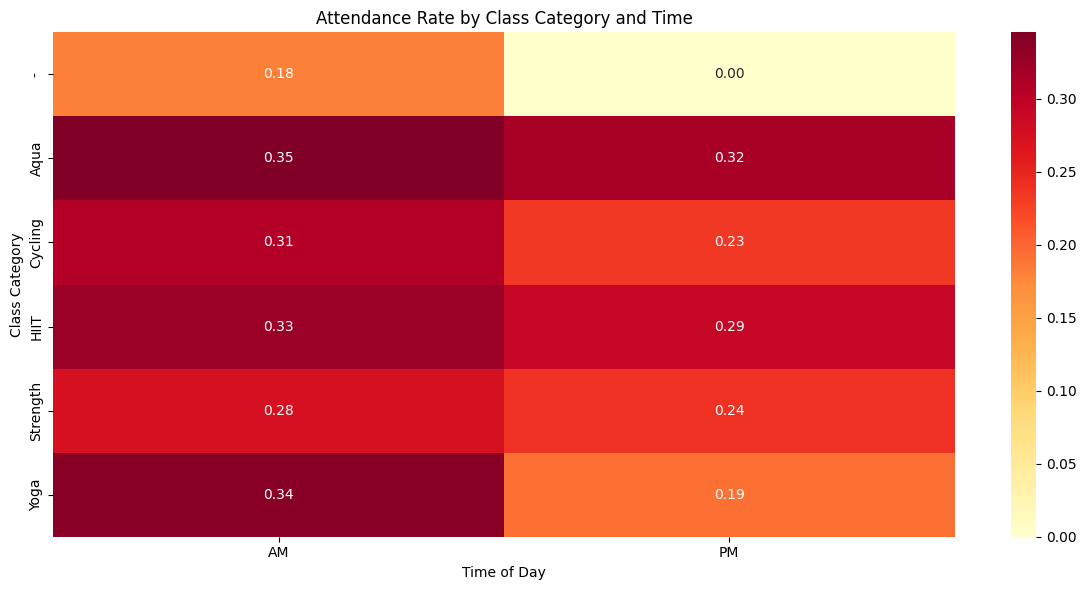

In [37]:
category_columns = [col for col in booking_df.columns if col.startswith('category_')]
booking_df['category_raw'] = booking_df[category_columns].idxmax(axis=1).str.replace('category_', '')

time_columns = [col for col in booking_df.columns if col.startswith('time_')]
booking_df['time_raw'] = booking_df[time_columns].idxmax(axis=1).str.replace('time_', '')

# 按课程和时间统计出席率
pivot = booking_df.groupby(['category_raw', 'time_raw'])['attended'].mean().unstack()

# 画热力图
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt=".2f")
plt.title('Attendance Rate by Class Category and Time')
plt.xlabel('Time of Day')
plt.ylabel('Class Category')
plt.tight_layout()
plt.show()
